# Integrated CLASP Pipeline

Tune parameters, save them, embed the selected dataset, save the embedded AnnData file, and plot the paired batch/label view.

In [7]:
import os

for name in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[name] = "1"
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("KMP_INIT_AT_FORK", "FALSE")

from clasp import (
    ClaspEstimator,
    EstimatorTuneParams,
    GraphTuneParams,
    LatentBOTuneParams,
    PreprocessTuneParams,
    TuneParams,
)
from clasp.notebook_utils import dataset_config, optimized_params_path, preprocess_params


Restart the kernel before running this notebook if native numerical libraries have already been imported. The first cell sets conservative OpenMP/thread settings.

In [8]:
selected_dataset = "cellrank_bone_marrow"
random_state = 0
run_tuning = True

# Optimization uses a small stratified subset. Increase this after the pipeline works end to end.
tuning_max_cells = 1000

# Final visualization can use more cells than optimization.
final_max_cells = 6000

# UMAP is the default embedding used for the final CLASP coordinates.
embedding_method = "umap"
embedding_epochs = 60

dataset = dataset_config(selected_dataset)
estimator = ClaspEstimator(
    batch_key=dataset["batch_key"],
    label_key=dataset["label_key"],
    n_components=100,
    random_state=random_state,
    embedding_method=embedding_method,
)
raw_adata = estimator.to_data(dataset["input_path"])
raw_adata


AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [9]:
base_preprocess = preprocess_params(dataset, n_top_genes=1500)
fixed_preprocess = {"max_cells": tuning_max_cells}
base_estimator = {"n_components": 60}
base_graph = {
    **dataset.get("graph", {}),
    "metric": "euclidean",
}

preprocess_search_space = {
    "n_top_genes": {"type": "int", "bounds": [500, 2000]},
}
estimator_search_space = {
    "n_components": {"type": "int", "bounds": [20, 100]},
}
graph_search_space = {
    "n_neighbors": {"type": "int", "bounds": [5, 35]},
    "intra_fraction": {"type": "float", "bounds": [0.2, 0.9]},
    "n_inter_edges": {"type": "int", "bounds": [1, 6]},
    "assignment_quantile": {"type": "float", "bounds": [0.1, 1.0]},
    "hubness_k": {"type": "int", "bounds": [3, 20]},
    "rank_correction": {"type": "categorical", "values": [False, True]},
    "edge_weighting": {"type": "categorical", "values": ["binary", "distance"]},
    "mutual_neighbors": {"type": "categorical", "values": [False, True]},
}

tune_params = TuneParams(
    preprocess=PreprocessTuneParams(
        base=base_preprocess,
        fixed=fixed_preprocess,
        search_space=preprocess_search_space,
    ),
    estimator=EstimatorTuneParams(
        base=base_estimator,
        search_space=estimator_search_space,
    ),
    graph=GraphTuneParams(
        base=base_graph,
        search_space=graph_search_space,
    ),
    pca_bo=LatentBOTuneParams(
        n_initial=6,
        latent_dim=3,
        n_iterations=4,
        embedding_model="pca",
        acquisition="ei",
        batch_size=1,
    ),
    run_gplvm_refinement=False,
    random_state=random_state,
    embedding_method=embedding_method,
    embedding_epochs=embedding_epochs,
)


In [10]:
if run_tuning:
    tune_result = estimator.tune(raw_adata, tune_params)
    params_path = tune_result.save(optimized_params_path(selected_dataset))
else:
    tune_result = None
    params_path = optimized_params_path(selected_dataset)

import json
payload = json.loads(params_path.read_text())
metadata = payload.get("metadata", {})
optimized_params = {
    "params_path": str(params_path),
    "best_model": metadata.get("best_model"),
    "best_score": metadata.get("best_score"),
    "preprocess_params": payload.get("preprocess_params", {}),
    "estimator_params": payload.get("estimator_params", {}),
    "graph_params": payload.get("graph_params", {}),
}
optimized_params

{'params_path': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/clasp/data/optimized_params/cellrank_bone_marrow_graph_params.json',
 'best_model': 'pca',
 'best_score': 0.76435,
 'preprocess_params': {'create_artificial_batch': True,
  'hvg_flavor': 'variance',
  'max_cells': 1000,
  'min_cell_genes': None,
  'min_gene_counts': 0,
  'n_top_genes': 980,
  'normalize': False},
 'estimator_params': {'n_components': 73},
 'graph_params': {'assignment_quantile': 1.0,
  'edge_weighting': 'distance',
  'hubness_correction': 'csls',
  'hubness_k': 11,
  'intra_fraction': 0.8999999999999999,
  'metric': 'euclidean',
  'mutual_neighbors': False,
  'n_inter_edges': 5,
  'n_neighbors': 35,
  'neighbor_mode': 'distance',
  'rank_correction': True,
  'symmetrize': True}}

In [11]:
tuned_preprocess = payload.get("preprocess_params", dataset.get("preprocess", {}))
tuned_estimator = payload.get("estimator_params", {})
tuned_graph = payload.get("graph_params", dataset.get("graph", {}))

# Final run can use more cells than optimization while preserving tuned settings.
final_preprocess = {**tuned_preprocess, "max_cells": final_max_cells}
estimator = ClaspEstimator(
    batch_key=dataset["batch_key"],
    label_key=dataset["label_key"],
    random_state=random_state,
    embedding_method=embedding_method,
    **tuned_estimator,
)
adata = estimator.preprocess(raw_adata, **final_preprocess)
adata.obsm["X_clasp"] = estimator.embed(
    adata,
    **tuned_graph,
    embedding_method=embedding_method,
    embedding_random_state=random_state,
    n_epochs=embedding_epochs,
)
estimator.save(adata, dataset["output_path"])
adata

AnnData object with n_obs × n_vars = 5780 × 980
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'sample'
    var: 'palantir', 'clasp_hvg_score', 'clasp_selected'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'clasp'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'X_clasp'
    layers: 'spliced', 'unspliced'

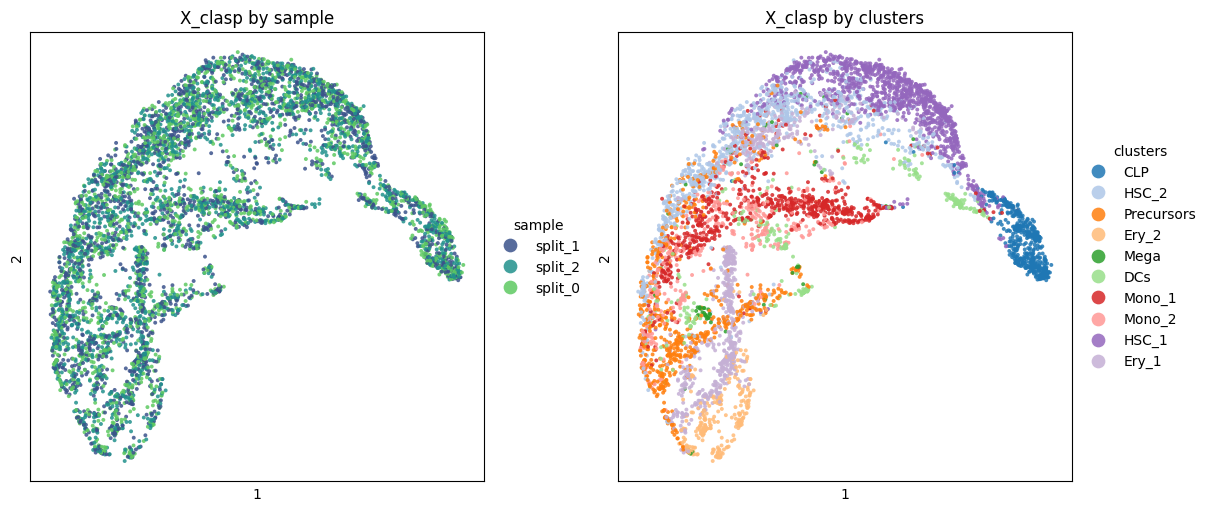

In [12]:
estimator.plot(
    adata,
    embedding_key="X_clasp",
    s=8,
    alpha=0.85,
    random_state=random_state,
    legend_markerscale=3.5,
);
